## IAPUCP - Modelos IA
### Autoencoders - Denoise

In [85]:
# Cargo librerias
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torchvision.datasets as Datasets
# ---- LÍNEAS AÑADIDAS ----
from torch.utils.data import DataLoader, random_split
# -------------------------

In [86]:
# 1. Definir las rutas correctas para cada conjunto de datos
# --- ¡RUTA CORREGIDA! ---
# (Se usa r"..." para que Windows lea la ruta correctamente)
ruta_train = r'C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_train'
ruta_pred = r'C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_test'
ruta_test = r'C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_test'

# 2. Definir las transformaciones
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_eval = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Cargar las imágenes y dividir el dataset
try:
    print(f"Cargando 'train_dataset' desde: {ruta_train}")
    train_dataset = torchvision.datasets.ImageFolder(
        root=ruta_train,
        transform=transform_train
    )

    print(f"Cargando 'test_dataset' desde: {ruta_test}")
    test_dataset = torchvision.datasets.ImageFolder(
        root=ruta_test,
        transform=transform_eval
    )

    # 4. Imprimir para verificar
    print(f"Datos de entrenamiento: {train_dataset}")
    print(f"Datos de prueba: {test_dataset}")


    # 5. Cargar datos de predicción
    # (ASEGÚRATE DE QUE ESTAS LÍNEAS NO ESTÉN COMENTADAS)
    print(f"Cargando 'pred_dataset' desde: {ruta_pred}")
    pred_dataset = torchvision.datasets.ImageFolder(
        root=ruta_pred,
        transform=transform_eval 
    )
    print(f"Datos de predicción: {pred_dataset}")


    # 6. Dividir el dataset de entrenamiento para validación
    print("\nDividiendo el dataset de entrenamiento...")
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size

    # Dividir el dataset (Ahora 'random_split' está importado)
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    print(f"Dataset de entrenamiento original: {len(train_dataset)} imágenes")
    print(f"Nuevo subset de entrenamiento: {len(train_subset)} imágenes")
    print(f"Nuevo subset de validación: {len(val_subset)} imágenes")
    
    # ---- CÓDIGO AÑADIDO (PARA ARREGLAR CELDAS FUTURAS) ----
    # Definir los DataLoaders aquí para usarlos después
    batch_size = 64
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"\nDataLoaders creados con tamaño de batch {batch_size}")
    # ----------------------------------------------------
    
    print("\n¡Carga de datos exitosa!")

except FileNotFoundError as e:
    print(f"\n--- ¡ERROR! NO SE ENCONTRÓ LA RUTA ---")
    print(f"Error específico: {e}")
except Exception as e:
    print(f"\n--- OTRO ERROR OCURRIÓ ---")
    print(f"Error específico: {e}")

Cargando 'train_dataset' desde: C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_train
Cargando 'test_dataset' desde: C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_test
Datos de entrenamiento: Dataset ImageFolder
    Number of datapoints: 14034
    Root location: C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_train
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Datos de prueba: Dataset ImageFolder
    Number of datapoints: 3000
    Root location: C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_test
    StandardTransform
Transform: Compose(
               Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224)

In [87]:
# Ejecutar en gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mostrando un batch de 64 imágenes de 'train_dataset':


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


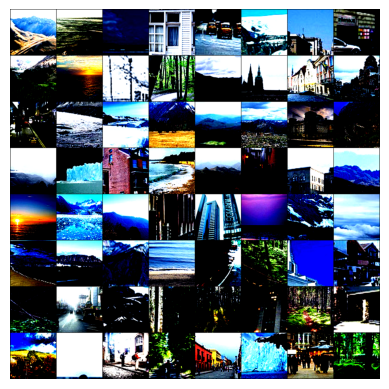

In [88]:
# --- 1. FUNCIÓN 'show_batch' CORREGIDA ---
def show_batch(imgs):
    if isinstance(imgs, np.ndarray):
        imgs = torch.tensor(imgs)
    if imgs.dtype == torch.uint8:
        imgs = imgs.float() / 255.0  # Solo normaliza si es uint8
    
    # --- LÍNEA CORREGIDA (Estaba faltando) ---
    grid = torchvision.utils.make_grid(imgs, nrow=8)
    # -----------------------------------------
    
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.show() # <-- Asegúrate que 'plt.show()' esté dentro de la función

# --- 2. BLOQUE TRY/EXCEPT CORREGIDO ---
try:
    # Crea un DataLoader temporal para visualizar
    # ---- ERROR CORREGIDO (Usa 'train_dataset') ----
    vis_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

    # Obtiene el primer batch de 64 imágenes
    imgs, labels = next(iter(vis_loader))

    # 3. Llama a tu función para mostrar el batch
    print("Mostrando un batch de 64 imágenes de 'train_dataset':")
    show_batch(imgs)

except NameError:
    print("--- ¡ERROR! ---")
    print("NameError: 'training_set' o 'train_dataset' no está definido.")
    print("Por favor, ejecuta la celda anterior (la que carga 'ImageFolder') primero.")
# --- ERROR CORREGIDO (Asegúrate que dice 'as e') ---
except Exception as e:
    print(f"Ocurrió un error: {e}")


In [89]:
# Se genera noise a las imágenes
def add_noise(imgs):
    noise = torch.randn_like(imgs) * 0.05
    noisy_imgs = imgs + noise
    return torch.clamp(noisy_imgs, 0., 1.)

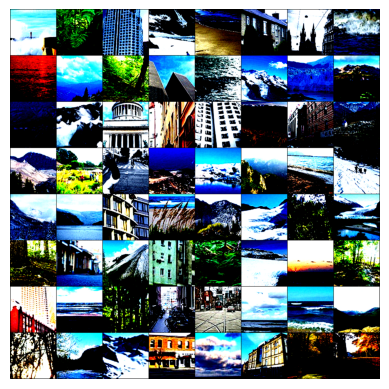

In [90]:
# se muestran un batch de imágenes con ruido

# --- LÓGICA CORREGIDA ---
# 1. Obtener un batch de imágenes usando el DataLoader (train_loader)
#    (Asegúrate de haber ejecutado la celda [23] corregida)
try:
    imgs, _ = next(iter(train_loader))
    
    # 2. Mueve las imágenes al dispositivo (CPU o GPU) y añade ruido
    imgs = imgs.to(device)
    noisy_imgs = add_noise(imgs)
    
    # 3. Muestra el batch con ruido
    #    (movemos las imágenes de vuelta a la CPU para que matplotlib pueda mostrarlas)
    show_batch(noisy_imgs.cpu())

except NameError as e:
    print(f"¡Error! Asegúrate de ejecutar la celda [23] corregida primero para definir 'train_loader'.")
    print(f"Error específico: {e}")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0592382..2.5603435].


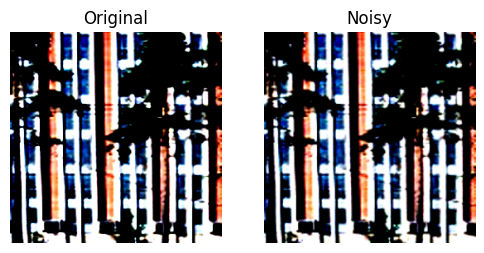

In [91]:
import torch.nn.functional as F

# --- CÓDIGO CORREGIDO ---
# Todo el código que depende de 'imgs' y 'noisy_imgs' 
# debe ir DENTRO del bloque 'try'.

try:
    # 1. Obtener un batch de imágenes y moverlas al 'device'
    #    (Asegúrate de haber ejecutado la celda [23] para 'train_loader' 
    #     y la celda [24] para 'device')
    imgs, _ = next(iter(train_loader))
    imgs = imgs.to(device)

    # 2. Generar las imágenes con ruido usando la función de la celda [26]
    #    (Asegúrate de haber ejecutado la celda [26] para definir 'add_noise')
    noisy_imgs = add_noise(imgs)

    # 3. Selecciona la primera imagen del batch y su versión con ruido
    original = imgs[0]
    noisy = noisy_imgs[0]

    # 4. Redimensiona para visualización
    original = F.interpolate(original.unsqueeze(0), size=(256, 256), mode='bilinear', align_corners=False).squeeze(0)
    noisy = F.interpolate(noisy.unsqueeze(0), size=(256, 256), mode='bilinear', align_corners=False).squeeze(0)

    # 5. Visualiza ambas imágenes
    def show_original_and_noisy(original, noisy):
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        
        # .cpu() es necesario para que numpy/matplotlib puedan leer el tensor si está en GPU
        axes[0].imshow(np.transpose(original.cpu().numpy(), (1, 2, 0)))
        axes[0].set_title('Original')
        axes[0].axis('off')
        axes[1].imshow(np.transpose(noisy.cpu().numpy(), (1, 2, 0)))
        axes[1].set_title('Noisy')
        axes[1].axis('off')
        plt.show()

    show_original_and_noisy(original, noisy)

# Si 'train_loader', 'device' o 'add_noise' no están definidos, saltará aquí
except NameError as e:
    print("--- ¡ERROR! ---")
    print(f"Error específico: {e}")
    print("\nAsegúrate de haber ejecutado en orden las celdas anteriores:")
    print("1. Celda [23] (para definir 'train_loader')")
    print("2. Celda [24] (para definir 'device')")
    print("3. Celda [26] (para definir 'add_noise')")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

In [92]:
# se usara cifar para la tarea de denoising
# se usara un autoencoder para eliminar el ruido

# se usara un modelo de autoencoder convolucional
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            # nn.Sigmoid()  <--- QUITA ESTA LÍNEA
            nn.Tanh()     # <--- AÑADE ESTA LÍNEA (Recomendado)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [93]:
# Proceso de entrenamiento del autoencoder

autoencoder = Autoencoder().to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
train_losses = []

# DataLoader para entrenamiento
# --- LÍNEA CORREGIDA ---
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)
# ---------------------

print("Iniciando entrenamiento...") # Añadido para confirmar
epochs = 40 # Mantenemos las 20 épocas de tu código original
for epoch in range(epochs):
    autoencoder.train()
    running_loss = 0.0
    
    # (El resto de tu bucle está perfecto)
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        noisy_imgs = add_noise(imgs)
        optimizer.zero_grad()
        outputs = autoencoder(noisy_imgs)
        loss = loss_fn(outputs, imgs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
    train_losses.append(epoch_loss)

print("¡Entrenamiento finalizado!") # Añadido para confirmar


Iniciando entrenamiento...
Epoch 1/40, Loss: 0.5813
Epoch 2/40, Loss: 0.3369
Epoch 3/40, Loss: 0.3152
Epoch 4/40, Loss: 0.3053
Epoch 5/40, Loss: 0.2965
Epoch 6/40, Loss: 0.2940
Epoch 7/40, Loss: 0.2888
Epoch 8/40, Loss: 0.2858
Epoch 9/40, Loss: 0.2825
Epoch 10/40, Loss: 0.2815
Epoch 11/40, Loss: 0.2770
Epoch 12/40, Loss: 0.2768
Epoch 13/40, Loss: 0.2756
Epoch 14/40, Loss: 0.2734
Epoch 15/40, Loss: 0.2729
Epoch 16/40, Loss: 0.2728
Epoch 17/40, Loss: 0.2683
Epoch 18/40, Loss: 0.2681
Epoch 19/40, Loss: 0.2680
Epoch 20/40, Loss: 0.2680
Epoch 21/40, Loss: 0.2656
Epoch 22/40, Loss: 0.2650
Epoch 23/40, Loss: 0.2650
Epoch 24/40, Loss: 0.2656
Epoch 25/40, Loss: 0.2634
Epoch 26/40, Loss: 0.2650
Epoch 27/40, Loss: 0.2624
Epoch 28/40, Loss: 0.2628
Epoch 29/40, Loss: 0.2634
Epoch 30/40, Loss: 0.2611
Epoch 31/40, Loss: 0.2618
Epoch 32/40, Loss: 0.2608
Epoch 33/40, Loss: 0.2590
Epoch 34/40, Loss: 0.2599
Epoch 35/40, Loss: 0.2609
Epoch 36/40, Loss: 0.2585
Epoch 37/40, Loss: 0.2604
Epoch 38/40, Loss: 0

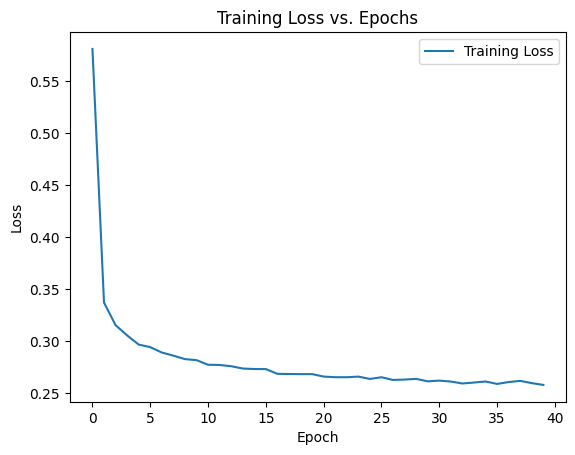

In [94]:
# Graficar las pérdidas de entrenamiento
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs. Epochs")
plt.legend()
plt.show()


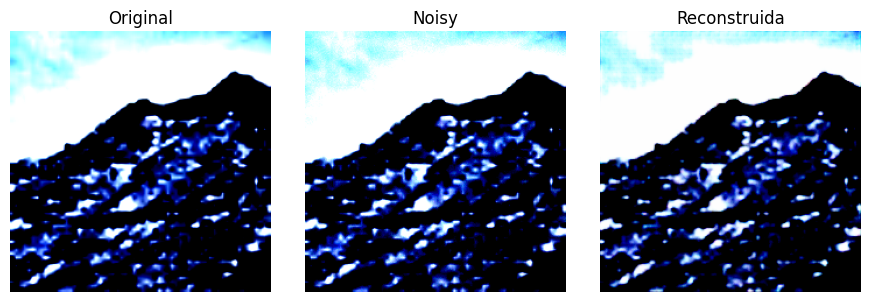

In [95]:
# Tomar un batch de imágenes del set de entrenamiento o test
imgs, _ = next(iter(train_loader))
imgs = imgs.to(device)
noisy_imgs = add_noise(imgs)
with torch.no_grad():
    reconstructed_imgs = autoencoder(noisy_imgs)

# Selecciona la primera imagen del batch
original = imgs[0].cpu()
noisy = noisy_imgs[0].cpu()
reconstructed = reconstructed_imgs[0].cpu()

# Visualiza las tres imágenes (original, noisy, reconstruida) correctamente alineadas
import matplotlib.pyplot as plt
import numpy as np

def show_images(original, noisy, reconstructed):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for ax, img, title in zip(axes, [original, noisy, reconstructed], ['Original', 'Noisy', 'Reconstruida']):
        img_np = img.numpy()
        img_np = np.transpose(img_np, (1, 2, 0))
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images(original, noisy, reconstructed)